# Prototype Fisher forecast for $\nu$LCDM with Alcock-Paczyński effect

Fisher forecast using `jax.jacfwd` and a Gaussian covariance for $P^\ell_{\mathrm{1-loop}}(k)$ where $\ell=[0,2,4]$
for a single redshift bin, **including the Alcock-Paczyński (AP) effect** and **massive neutrinos** ($m_\nu$) as a free parameter.

Key differences from `fisher_prototype_AP.ipynb`:
- Uses the `jense_2023_camb_mnu` emulator which includes $m_\nu$ as an input parameter.
- H(z) and $D_A(z)$ are computed analytically via `ps_1loop_jax.background` , which includes the neutrino contribution $\Omega_\nu = m_\nu / (93.14\,h^2)$ in the Friedmann equation.
- The growth rate $f(z)$ also accounts for massive neutrinos through $\Omega_m(z)$.

## Modules

In [1]:
import os

### matplotlib

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22})

from matplotlib.ticker import MultipleLocator, FormatStrFormatter

### numpy

import numdifftools as nd
import numpy as np

### jax

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.scipy as jsp

### background cosmology

from ps_1loop_jax import background as bg

### jaxptpolypol

from jaxptpolypol.model import CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_pk_params,
    unpack_pk_params,
)
from jaxptpolypol.covariance import gaussian_covariance
from jaxptpolypol.inference import fisher_matrix, marginalize_fisher, sigma_from_fisher
from jaxptpolypol.plotting import plot_contours, plot_Gaussian, triangle_plot
from jaxptpolypol.theory import make_pk_ell_fn, compute_fiducial_distances

## Emulator and model classes

## Initialize emulators and model

We use the `jense_2023_camb_mnu` emulator (flat $\nu$LCDM with baryon feedback + $m_\nu$) from [Jense et al. 2024](https://arxiv.org/abs/2306.10271).

Parameters: `['ombh2', 'omch2', 'logA', 'ns', 'h', 'z', 'A_b', 'eta_b', 'logT_AGN', 'mnu']`

In [2]:
model_path = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Pk_lin.npz'

pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=model_path)
print("Emulator input parameters:", pklin_emulator.parameters)
print("Emulator k range:", pklin_emulator.modes[0], "-", pklin_emulator.modes[-1], "Mpc^{-1}")

ps1loop_model = PS1LoopModel(do_irres=True)
print("1-loop Pk terms:", ps1loop_model.pk_terms)

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Emulator input parameters: ['ombh2' 'omch2' 'logA' 'ns' 'h' 'z' 'A_b' 'eta_b' 'logT_AGN' 'mnu']
Emulator k range: 4.999999999999999e-05 - 49.99999999999999 Mpc^{-1}
1-loop Pk terms: ['22_dd', '13_dd', 'I_d2', 'I_G2', 'I_d2_d2', 'I_G2_G2', 'I_d2_G2', 'F_G2']


## Cosmology and survey parameter classes

## Fiducial cosmology and survey parameters

### Cosmological parameters

Planck 2018 TT,TE,EE+lowE+lensing+BAO fiducial, with $m_\nu = 0.06$ eV.

In [3]:
cosmo_dict = {
    'ombh2':   0.02242,
    'omch2':   0.11933,
    'logA':    3.047,
    'ns':      0.9665,
    'h':       0.6766,
    'z':       1.1,
    'A_b':     3.13,
    'eta_b':   0.603,
    'logT_AGN': 7.8,
    'mnu':     0.06,     # sum of neutrino masses [eV]
}
cosmo = CosmoParams(cosmo_dict)
print(cosmo)

CosmoParams:
  ombh2: 0.02242
  omch2: 0.11933
  logA: 3.047
  ns: 0.9665
  h: 0.6766
  z: 1.1
  A_b: 3.13
  eta_b: 0.603
  logT_AGN: 7.8
  mnu: 0.06


### Survey parameters

Parameters for PFS redshift bin 1 ($0.6 < z < 0.8$, $z_\mathrm{eff}=0.7$).

In [4]:
ells = [0, 2, 4]          # multipoles
V    = 1.09*(1000.**3)    # survey volume [Mpc/h]^3
knl  = 1.02               # nonlinear scale [h/Mpc]
ndens = 9.75e-4           # galaxy number density [h/Mpc]^3

In [5]:
# Bias fitting functions from Eq. (3.6)-(3.14) of arXiv:1907.06666
def b1z(z): return 0.9 + 0.4*z
def b2z(z): return -0.704 - 0.208*z + 0.183*z**2 - 0.00771*z**3
def bG2z(z): return -(2./7.)*(b1z(z) - 1.)
def bGamma3z(z): return (23./42.)*(b1z(z) - 1.)

# Linear growth factor D+(z) via ps_1loop_jax.background (Heath integral, includes mnu)
def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z,
        mnu=cosmo_dict['mnu']
    ))

def c0z(z): return 25.*Dplusz(z)**2
def c2z(z): return 25.*Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

In [6]:
survey = FullShapeSurveyParams(
    shared={
        'bias': {
            'b1':      b1z(cosmo_dict['z']),
            'b2':      b2z(cosmo_dict['z']),
            'bG2':     bG2z(cosmo_dict['z']),
            'bGamma3': bGamma3z(cosmo_dict['z']),
        },
        'stoch': {
            'P_shot': 1.0,
        },
        'k_nl': knl,
        'ndens': ndens,
    },
    pk={
        'ctr': {
            'c0':   c0z(cosmo_dict['z']),
            'c2':   c2z(cosmo_dict['z']),
            'c4':   c4z(cosmo_dict['z']),
            'cfog': knl**(-4),
        },
        'stoch': {
            'a0': 0.,
            'a2': 0.,
        },
    },
)
pk_survey_keys = survey.pk_param_keys
print(survey)


SurveyParams:
  bias:
    b1: 1.34
    b2: -0.72163
    bG2: -0.097143
    bGamma3: 0.18619
  ctr:
    c0: 8.4809
    c2: 8.4809
    c4: 0.33924
    cfog: 0.92385
  stoch:
    P_shot: 1
    a0: 0
    a2: 0
  k_nl: 1.02
  ndens: 0.000975


### Helpers: pack / unpack

In [7]:
packed_params = pack_pk_params(cosmo, [survey])
print("Packed parameter vector:\n", packed_params)
print("Number of parameters:", packed_params.shape[0])

u_cosmo, u_surveys = unpack_pk_params(
    packed_params,
    cosmo.param_keys,
    cosmo.param_sizes,
    pk_survey_keys,
    n_bins=1,
)
u_survey = u_surveys[0]
print("Cosmo round-trip:", u_cosmo == cosmo)
print("Survey round-trip:", u_survey == survey)


Packed parameter vector:
 [ 2.24200000e-02  1.19330000e-01  3.04700000e+00  9.66500000e-01
  6.76600000e-01  1.10000000e+00  3.13000000e+00  6.03000000e-01
  7.80000000e+00  6.00000000e-02  1.34000000e+00 -7.21632010e-01
 -9.71428571e-02  1.86190476e-01  8.48094646e+00  8.48094646e+00
  3.39237858e-01  9.23845426e-01  1.00000000e+00  0.00000000e+00
  0.00000000e+00  1.02000000e+00  9.75000000e-04]
Number of parameters: 23
Cosmo round-trip: True
Survey round-trip: True


## Fiducial $H(z)$ and $D_A(z)$ via `ps_1loop_jax.background`

We precompute the fiducial distances once (as plain floats). Inside the differentiable wrapper,
the `bg.Hz` and `bg.angular_diameter_distance` functions are called with traced parameters.

Units are physical: $H(z)$ in km/s/Mpc, $D_A(z)$ in Mpc.

In [8]:
z_fid = cosmo_dict['z']
mnu_fid = cosmo_dict['mnu']
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, (z_fid,), mnu=mnu_fid)
print(f"Fiducial H(z={z_fid})  = {Hz_fid[0]:.4f} km/s/Mpc")
print(f"Fiducial D_A(z={z_fid}) = {DAz_fid[0]:.4f} Mpc")

Fiducial H(z=1.1)  = 127.8322 km/s/Mpc
Fiducial D_A(z=1.1) = 1732.1076 Mpc


## Differentiable wrapper

The wrapper computes $\alpha_\perp$ and $\alpha_\parallel$ from `ps_1loop_jax.background`
(which includes $m_\nu$ in the Friedmann equation) and passes them to `ps_1loop_jax.get_pk_ell_ref()`.

In [9]:
# Wrapper built by make_pk_ell_fn

In [10]:
pk_fn = make_pk_ell_fn(
    ells=(0, 2, 4),
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    ap=True,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    n_gl=16,
)
jitted_wrapper = jax.jit(pk_fn)


## Sanity check: power spectrum multipoles

In [11]:
k_test = jnp.linspace(1e-4, 0.4, 100)
ells_tuple = (0, 2, 4)

jitted_wrapper(packed_params, k=k_test).block_until_ready()
%time pk_ells_test = jitted_wrapper(packed_params, k=k_test)
pk_ells_test = pk_ells_test.reshape(len(ells_tuple), k_test.shape[0])

CPU times: user 389 ms, sys: 37.3 ms, total: 426 ms
Wall time: 47.2 ms


Text(0.5, 1.0, '$P^{\\ell}_{\\mathrm{1-loop}}$ with AP ($\\nu$LCDM)')

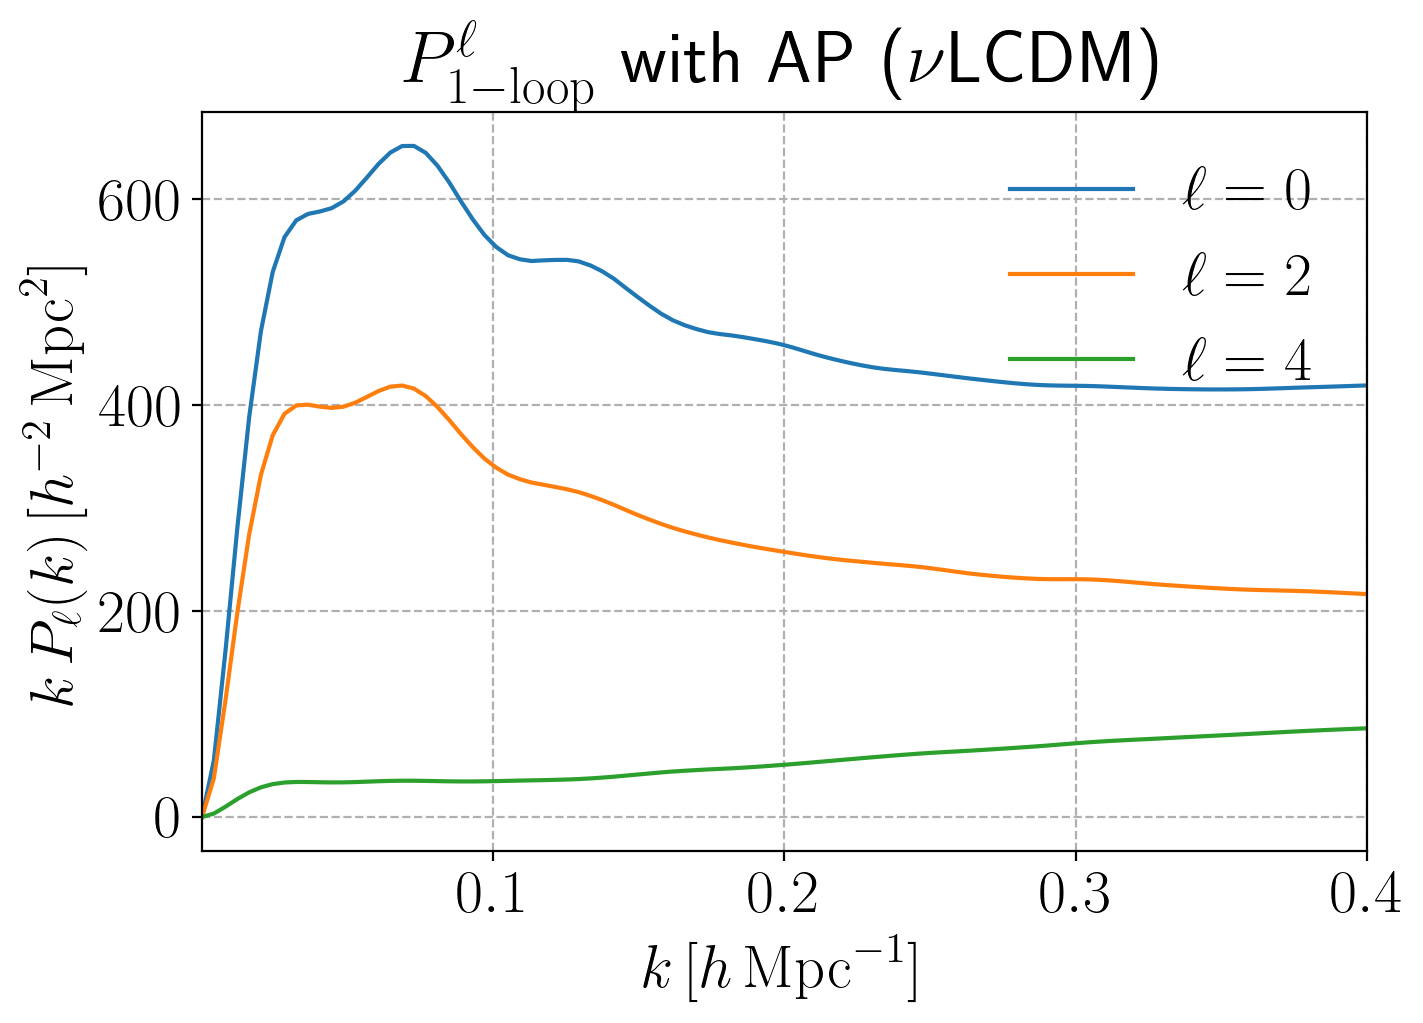

In [12]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for l, ell in enumerate(ells_tuple):
    ax.plot(k_test, k_test * pk_ells_test[l], label=r'$\ell = %d$' % ell)
ax.set_xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
ax.set_xlim(k_test.min(), k_test.max())
ax.legend(frameon=False)
ax.grid(linestyle='--')
ax.set_title(r'$P^{\ell}_{\mathrm{1-loop}}$ with AP ($\nu$LCDM)')

## Jacobian

In [13]:
k = jnp.linspace(5e-3, 0.25, 50)

%time jac = jax.jacfwd(jitted_wrapper, argnums=0)(packed_params, k=k)
print("Jacobian shape:", jac.shape)

CPU times: user 28.6 s, sys: 1.17 s, total: 29.8 s
Wall time: 10.9 s
Jacobian shape: (150, 23)


### Compare JAX autodiff vs finite differences

In [14]:
%time jac_nd = nd.Jacobian(lambda p: jitted_wrapper(p, k=k), step=2e-4)(packed_params)
print("Jacobian shape (nd):", jac_nd.shape)

CPU times: user 24.4 s, sys: 2.13 s, total: 26.5 s
Wall time: 5.83 s
Jacobian shape (nd): (150, 23)


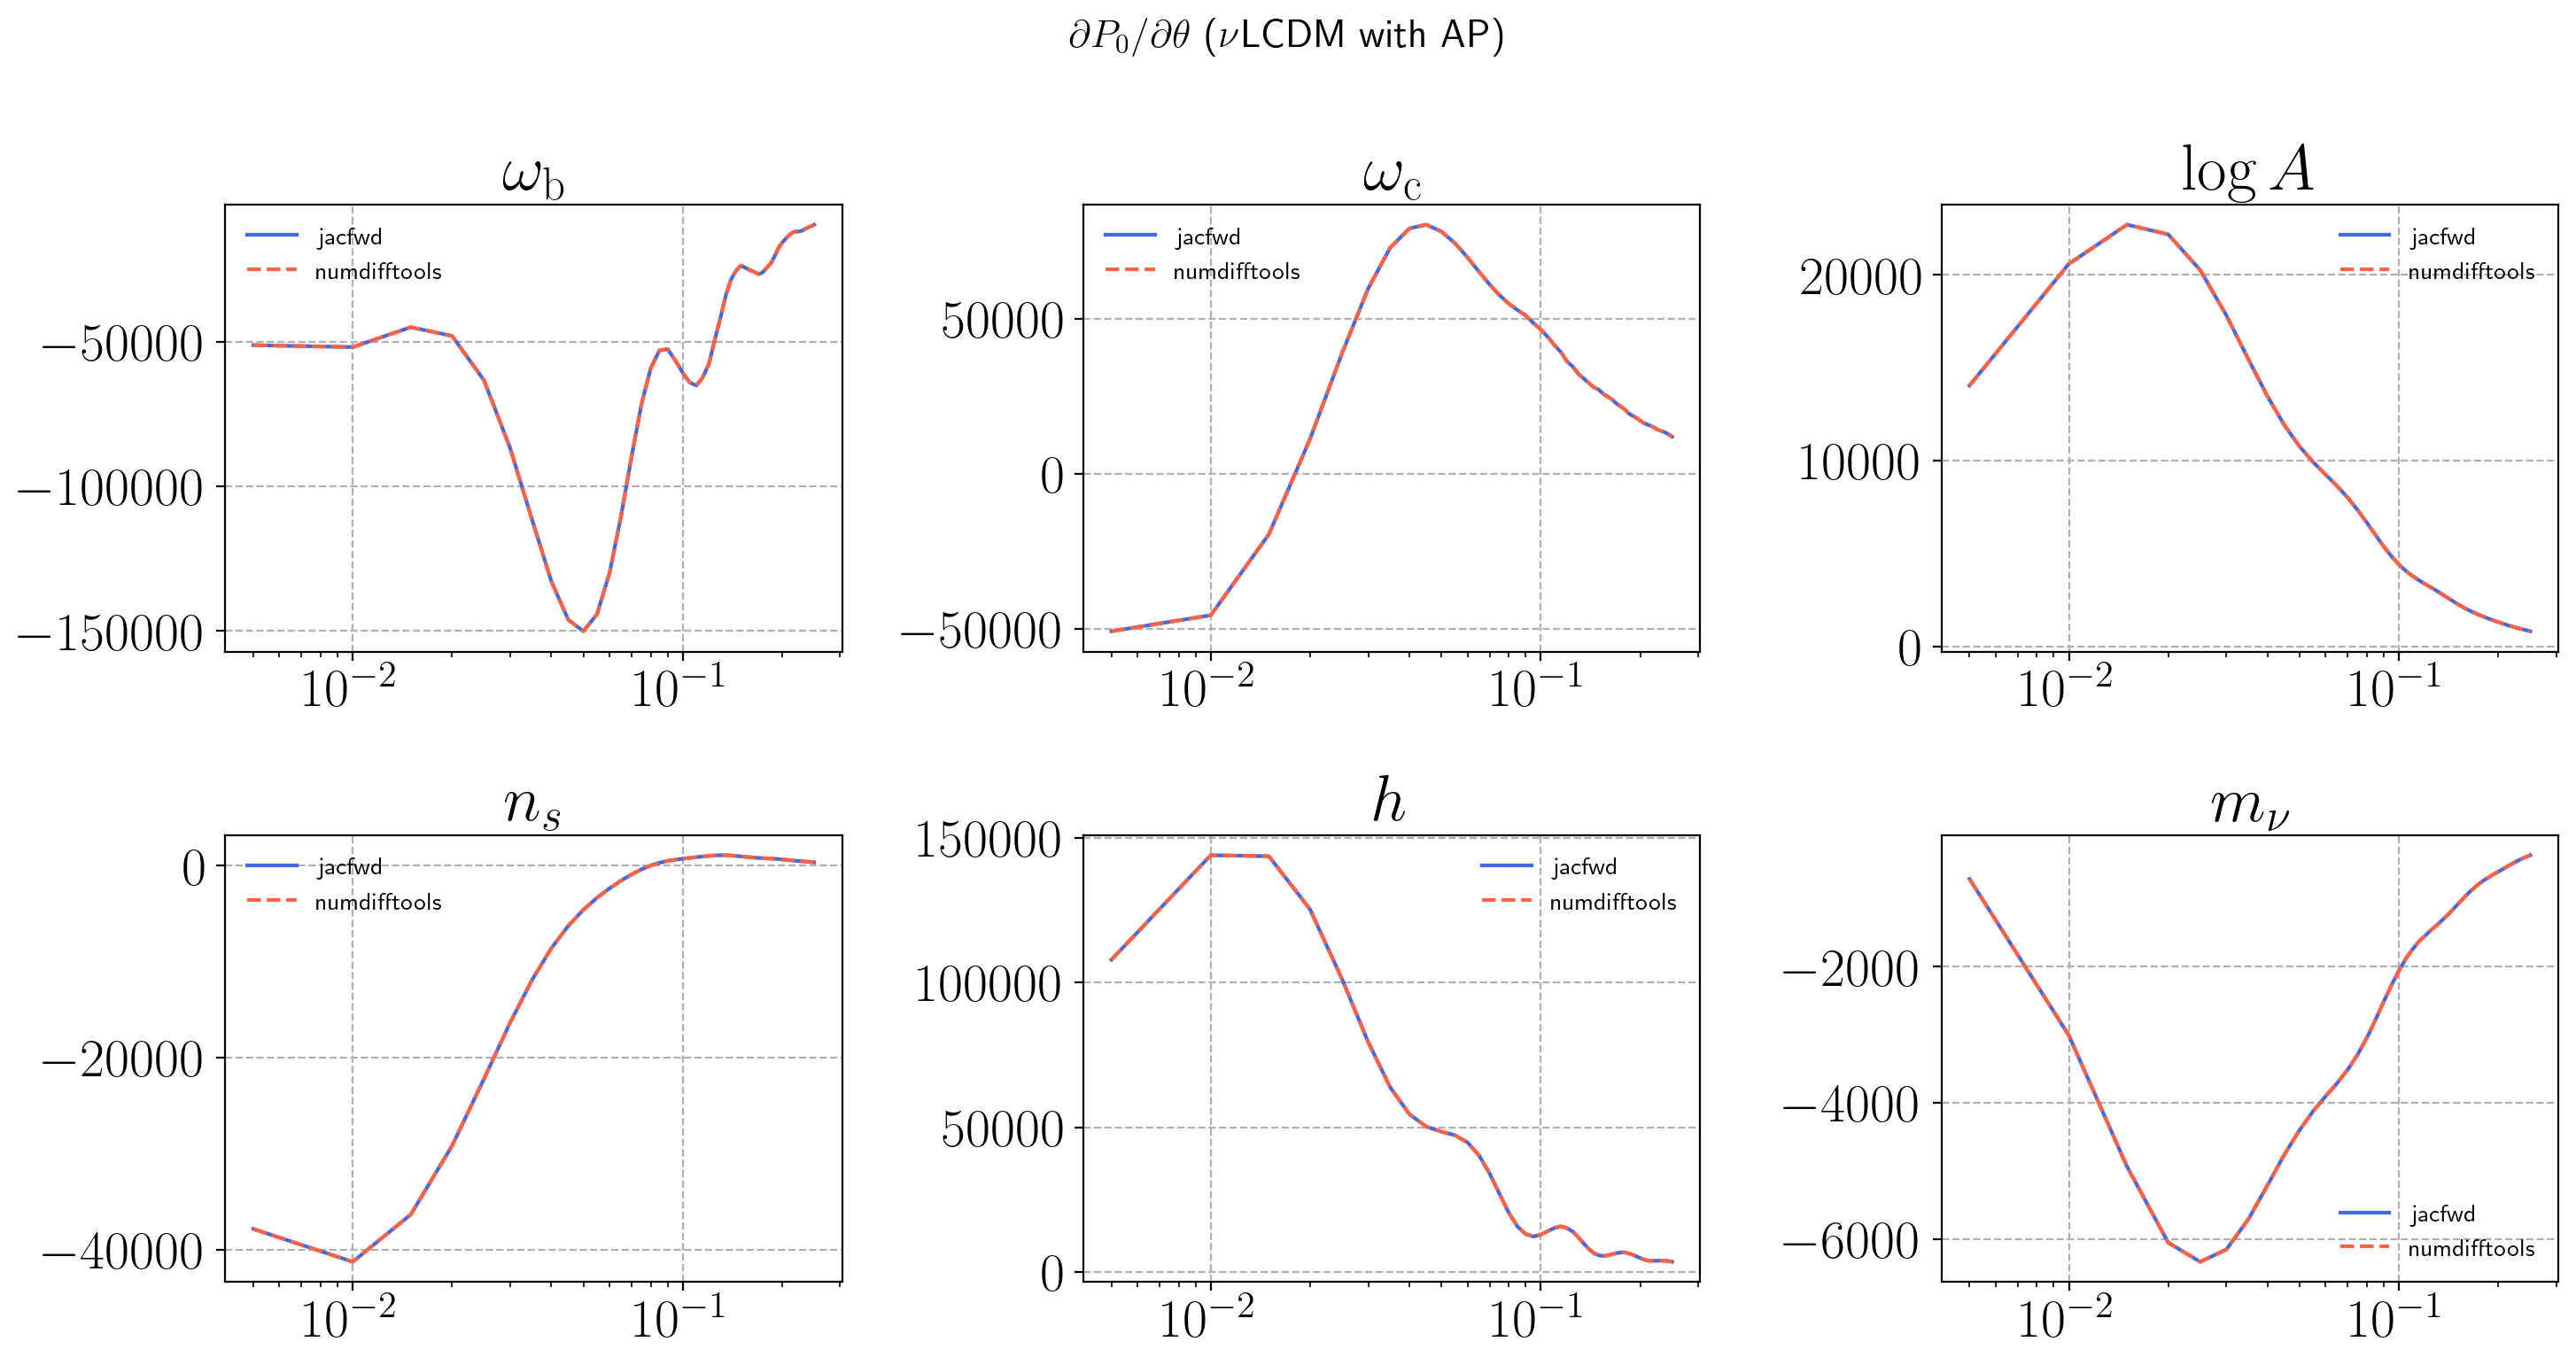

In [15]:
# Include mnu in the comparison
cosmo_labels = (r'$\omega_\mathrm{b}$', r'$\omega_\mathrm{c}$', r'$\log A$', r'$n_s$', r'$h$', r'$m_\nu$')
cosmo_idx    = [0, 1, 2, 3, 4, 9]  # indices in packed_params: ombh2, omch2, logA, ns, h, mnu

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
for idx, (i, j) in enumerate([(r, c) for r in range(2) for c in range(3)]):
    ax = axs[i, j]
    if idx >= len(cosmo_labels):
        ax.axis('off')
        continue
    ci = cosmo_idx[idx]
    ax.semilogx(k, jac[:k.shape[0], ci],    color='royalblue', label='jacfwd')
    ax.semilogx(k, jac_nd[:k.shape[0], ci], color='tomato', ls='--', label='numdifftools')
    ax.set_title(cosmo_labels[idx])
    ax.legend(fontsize=10, frameon=False)
    ax.grid(linestyle='--')
plt.suptitle(r'$\partial P_0 / \partial \theta$  ($\nu$LCDM with AP)', fontsize=16)
plt.tight_layout()

## Gaussian covariance

In [16]:
# gaussian_covariance imported from jaxptpolypol.covariance

In [17]:
ps1loop_ells = jitted_wrapper(packed_params, k=k).reshape(len(ells_tuple), k.shape[0])
gauss_cov = gaussian_covariance(V, k, k[1]-k[0], *ps1loop_ells)
print("Covariance shape:", gauss_cov.shape)

Covariance shape: (150, 150)


## Fisher matrix

In [18]:
# fisher_matrix imported from jaxptpolypol.inference

fisher = fisher_matrix(gauss_cov, jac)
print("Fisher matrix shape:", fisher.shape)

Fisher matrix shape: (23, 23)


## Fisher contours

In [19]:
# plot_contours, plot_Gaussian imported from jaxptpolypol.plotting

Varied parameter indices: [0, 1, 2, 3, 4, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Number of varied parameters: 17
Cosmo param positions in marginalized Fisher: [0 1 2 3 4 5]


Text(0.5, 0.98, '$P^{\\ell=[0,2,4]}_{\\rm with\\,AP}$ forecast ($\\nu$LCDM, bin 1, $z_{\\rm eff}=0.7$)')

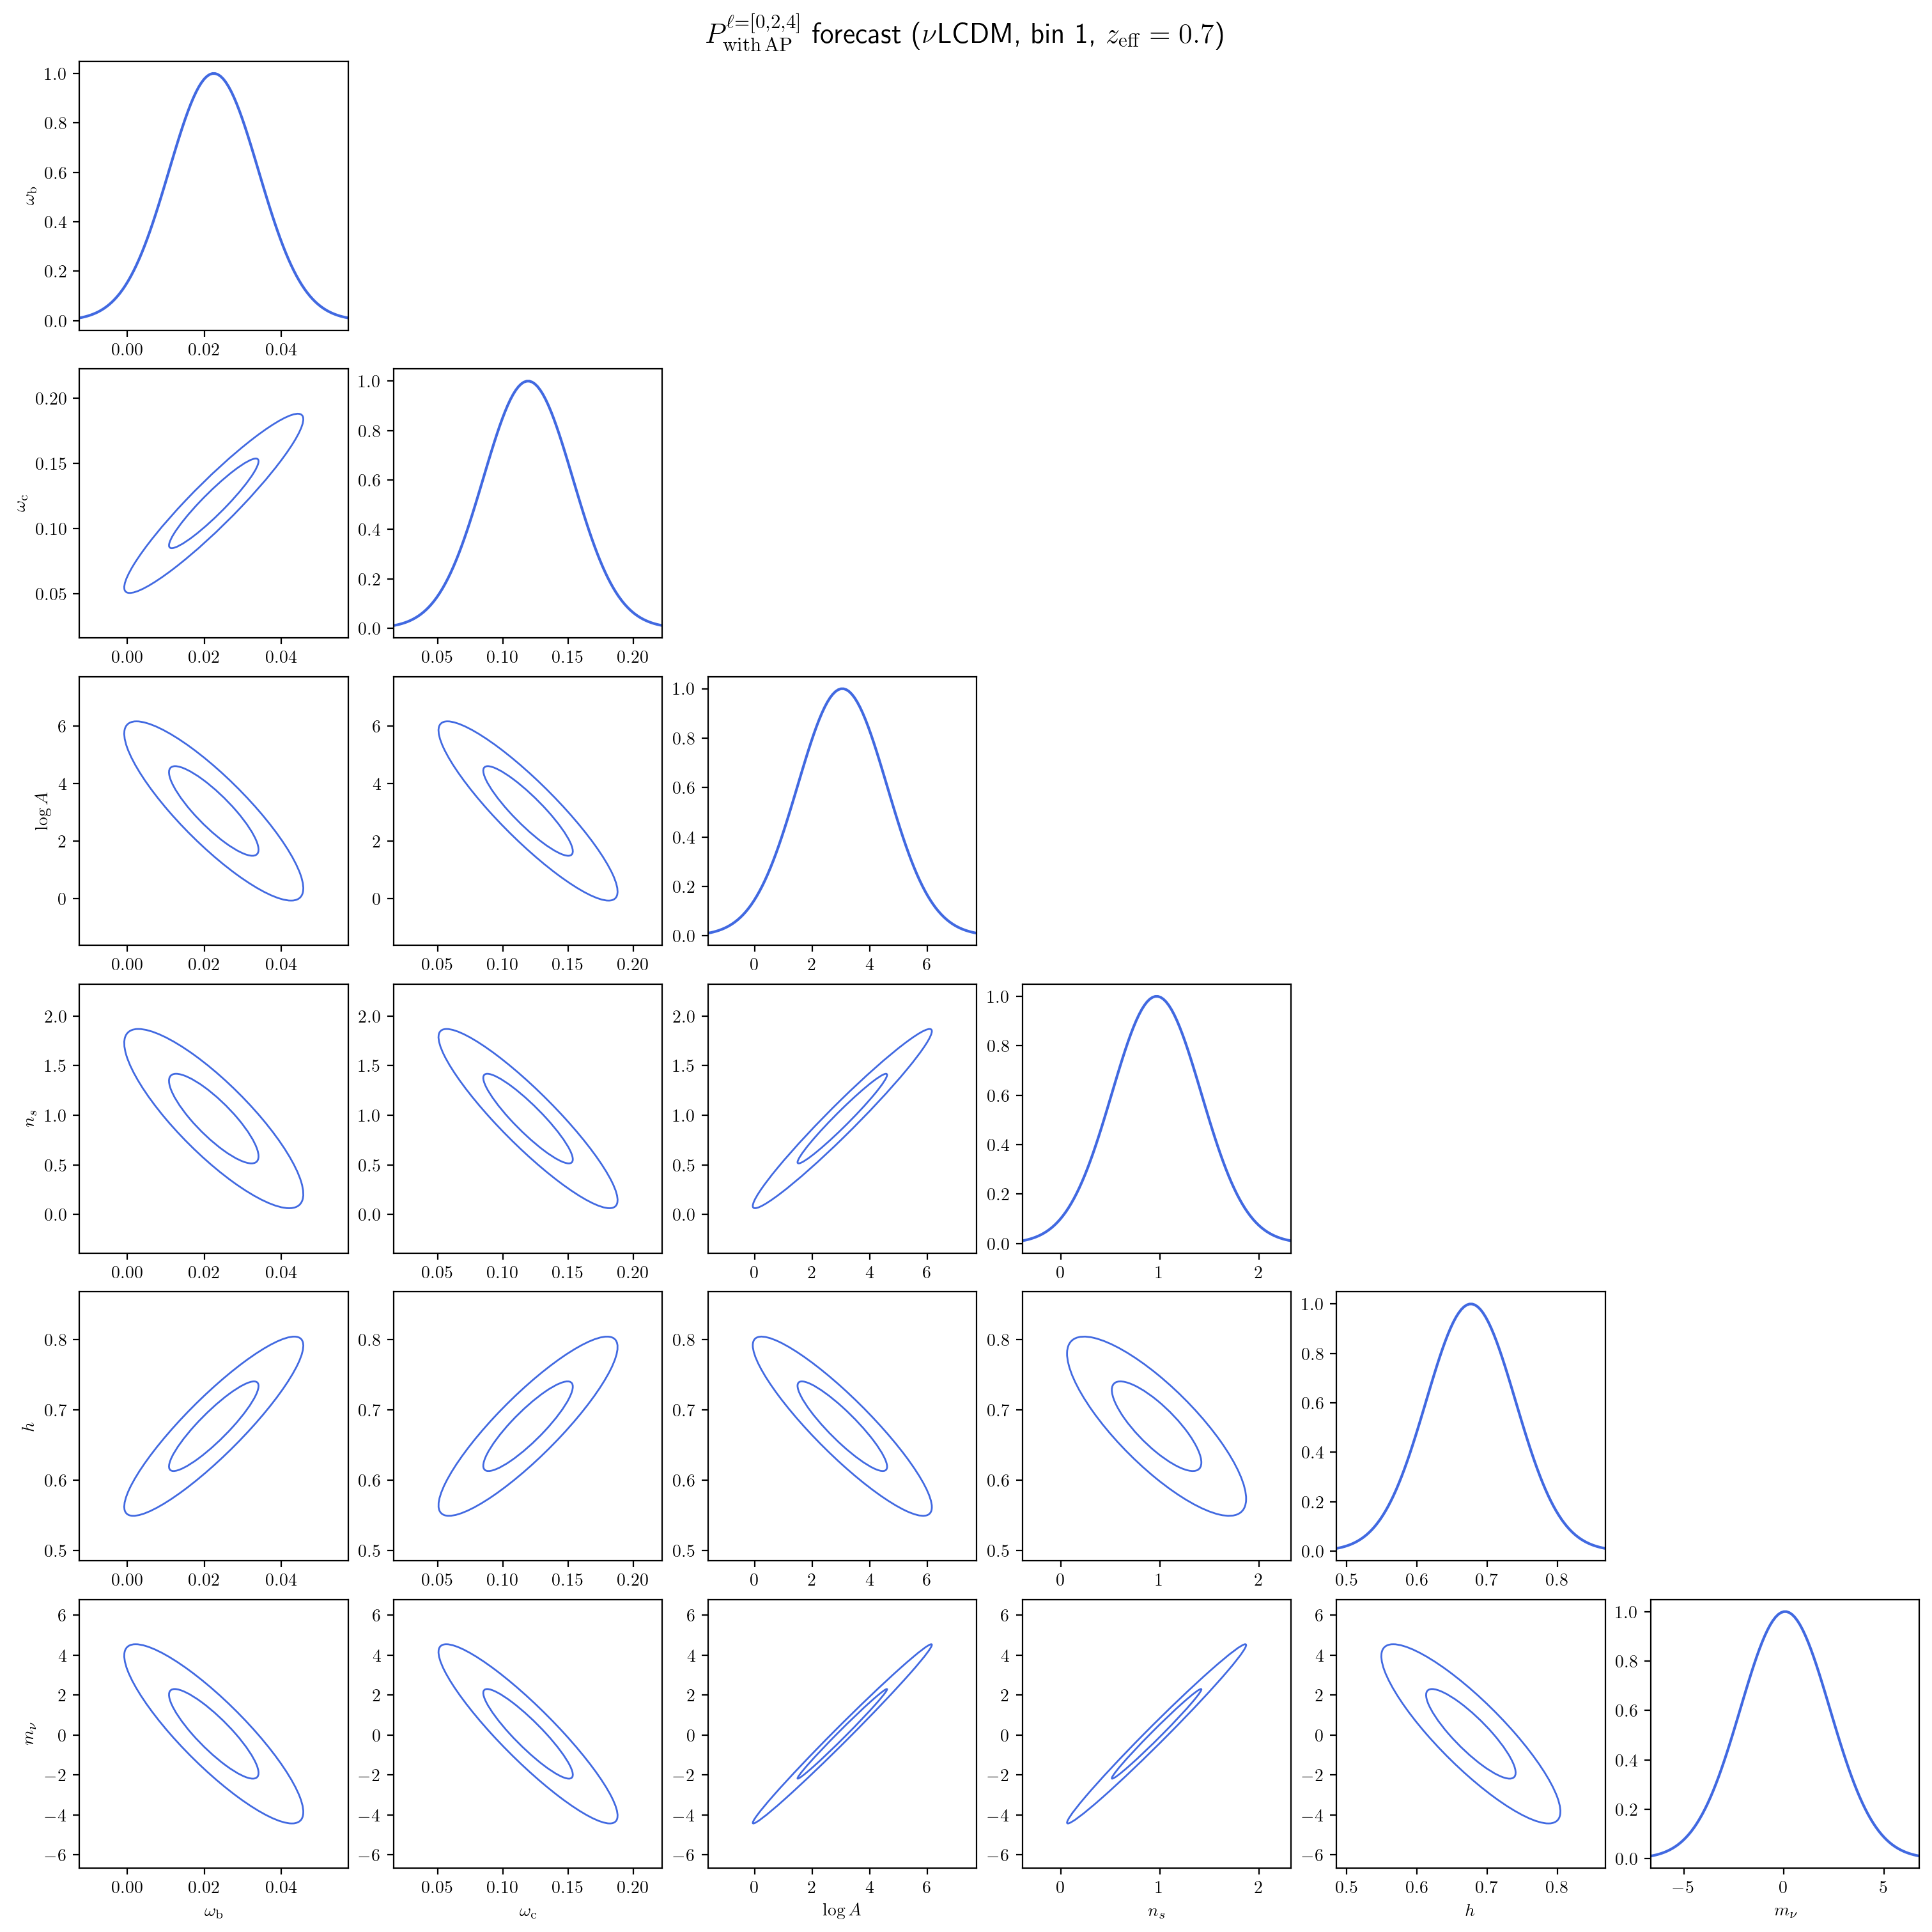

In [20]:
# nuLCDM: 6 cosmological parameters including mnu
cosmo_param_names = (
    r'$\omega_\mathrm{b}$', r'$\omega_\mathrm{c}$', r'$\log A$',
    r'$n_s$', r'$h$', r'$m_\nu$'
)
n_cosmo_plot = len(cosmo_param_names)
cosmo_plot_idx = np.array([0, 1, 2, 3, 4, 9])  # ombh2, omch2, logA, ns, h, mnu

all_idx = list(range(fisher.shape[0]))
fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets = [i for i, key in enumerate(pk_survey_keys) if key in fixed_survey_keys]
fixed_idx = [5, 6, 7, 8] + [len(cosmo.param_keys) + i for i in fixed_survey_offsets]
varied_idx = [i for i in all_idx if i not in fixed_idx]
print("Varied parameter indices:", varied_idx)
print("Number of varied parameters:", len(varied_idx))

F_marg = fisher[np.ix_(varied_idx, varied_idx)]

# Map cosmo_plot_idx to their position in the marginalized Fisher matrix
cosmo_marg_idx = np.array([varied_idx.index(i) for i in cosmo_plot_idx])
print("Cosmo param positions in marginalized Fisher:", cosmo_marg_idx)

# Fiducial values for the plot axes
packed_varied = packed_params[np.array(varied_idx)]

plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(n_cosmo_plot*2.5, n_cosmo_plot*2.5), constrained_layout=True)

for i in range(n_cosmo_plot):
    for j in range(n_cosmo_plot):
        ax = plt.subplot(n_cosmo_plot, n_cosmo_plot, i*n_cosmo_plot+j+1)
        if j < i:
            plot_contours(F_marg, packed_varied, np.array([cosmo_marg_idx[j], cosmo_marg_idx[i]]),
                          fill=False, color='royalblue')
        elif j == i:
            plot_Gaussian(F_marg, packed_varied, cosmo_marg_idx[i], color='royalblue')
        else:
            ax.axis('off')
        if i == n_cosmo_plot - 1:
            plt.xlabel(cosmo_param_names[j])
        if j == 0:
            plt.ylabel(cosmo_param_names[i])

fig.suptitle(r'$P^{\ell=[0,2,4]}_{\rm with\,AP}$ forecast ($\nu$LCDM, bin 1, $z_{\rm eff}=0.7$)', fontsize=16)


## Marginalized 1$\sigma$ constraints

In [21]:
from jax.scipy.linalg import inv
from jaxptpolypol.chain_analysis import make_fullshape_spec

F_inv = inv(F_marg)
sigma_marg = jnp.sqrt(jnp.diag(F_inv))

spec = make_fullshape_spec(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    n_bins=1,
    varied_idx=varied_idx,
    analysis_kind='pk',
)
all_varied_names = list(spec.varied_param_names())

print("Marginalized 1-sigma constraints (nuLCDM with AP):")
print("="*55)
for i, name in enumerate(all_varied_names):
    fid_val = float(packed_varied[i])
    sig = float(sigma_marg[i])
    print(f"  {name:20s}:  fid = {fid_val:12.5g},  sigma = {sig:12.5g}")

print("\nCosmological parameters only:")
for name, midx in zip(cosmo_param_names, cosmo_marg_idx):
    fid_val = float(packed_varied[midx])
    sig = float(sigma_marg[midx])
    print(f"  {name:20s}:  fid = {fid_val:12.5g},  sigma = {sig:12.5g},  sigma/fid = {abs(sig/fid_val):8.3%}")


Marginalized 1-sigma constraints (nuLCDM with AP):
  ombh2               :  fid =      0.02242,  sigma =     0.011626
  omch2               :  fid =      0.11933,  sigma =     0.034285
  logA                :  fid =        3.047,  sigma =       1.5551
  ns                  :  fid =       0.9665,  sigma =      0.45182
  h                   :  fid =       0.6766,  sigma =     0.063721
  mnu                 :  fid =         0.06,  sigma =       2.2413
  bias.b1             :  fid =         1.34,  sigma =       0.2692
  bias.b2             :  fid =     -0.72163,  sigma =       37.302
  bias.bG2            :  fid =    -0.097143,  sigma =       20.382
  bias.bGamma3        :  fid =      0.18619,  sigma =       60.149
  ctr.c0              :  fid =       8.4809,  sigma =       172.16
  ctr.c2              :  fid =       8.4809,  sigma =       111.39
  ctr.c4              :  fid =      0.33924,  sigma =       30.906
  ctr.cfog            :  fid =      0.92385,  sigma =       93.842
  stoch.P_s